<a href="https://colab.research.google.com/github/abtimist/ML-Project/blob/main/Int.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install kaggle API
!pip install kaggle -q

# Upload your kaggle.json API key first, then:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d what it is (search "Intrusion Detection System KDD" on Kaggle)
!unzip *.zip

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Define all 41 feature names + target
cols = """duration,protocol_type,service,flag,src_bytes,dst_bytes,land,
wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,
root_shell,su_attempted,num_root,num_file_creations,num_shells,
num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,
srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,
same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,
dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,
dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,
dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,
dst_host_srv_rerror_rate"""

columns = [c.strip() for c in cols.split(',') if c.strip()]
columns.append('target')
print(f"Total columns: {len(columns)}")

# Attack type mapping
attacks_types = {
    'normal': 'normal', 'back': 'dos', 'buffer_overflow': 'u2r',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l',
    'ipsweep': 'probe', 'land': 'dos', 'loadmodule': 'u2r',
    'multihop': 'r2l', 'neptune': 'dos', 'nmap': 'probe',
    'perl': 'u2r', 'phf': 'r2l', 'pod': 'dos', 'portsweep': 'probe',
    'rootkit': 'u2r', 'satan': 'probe', 'smurf': 'dos', 'spy': 'r2l',
    'teardrop': 'dos', 'warezclient': 'r2l', 'warezmaster': 'r2l',
}

# Load dataset (update filename if different)
df = pd.read_csv('/content/kddcup.data_10_percent/kddcup.data_10_percent', names=columns)

# Add Attack Type column (strip trailing dot from target values)
df['Attack Type'] = df['target'].apply(lambda r: attacks_types.get(r.strip('.'), 'unknown'))

print(f"Dataset shape: {df.shape}")
df.head()

Total columns: 42
Dataset shape: (494021, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,normal


Missing values:
 0


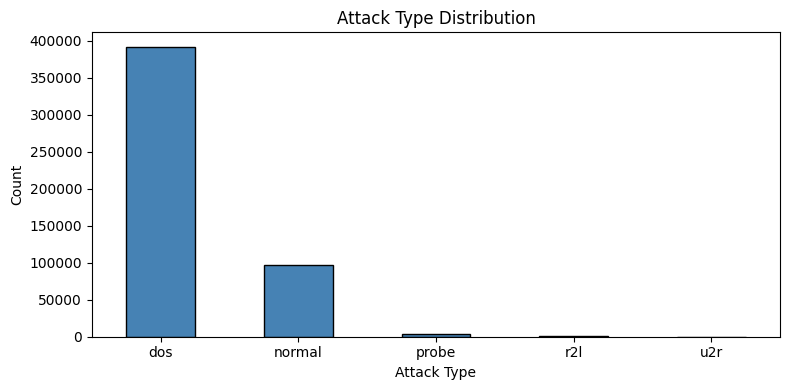

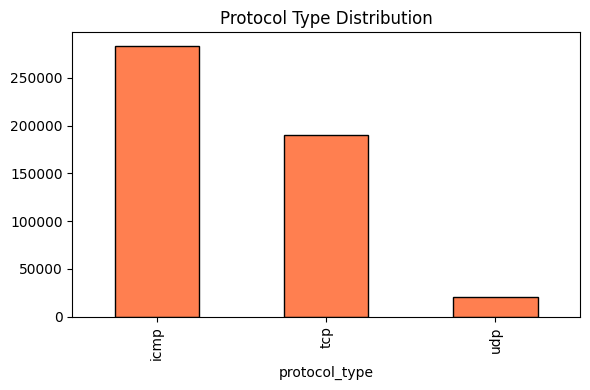

In [ ]:
# Check for missing values
print("Missing values:\n", df.isnull().sum().sum())

# Attack type distribution
plt.figure(figsize=(8, 4))
df['Attack Type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Attack Type Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Protocol type distribution
plt.figure(figsize=(6, 4))
df['protocol_type'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Protocol Type Distribution')
plt.tight_layout()
plt.show()

In [ ]:
# Droping original target column, keep Attack Type
df = df.drop(['target'], axis=1)

# Separate features and label
y = df['Attack Type']
X = df.drop(['Attack Type'], axis=1)

# Encode protocol_type
pmap = {'icmp': 0, 'tcp': 1, 'udp': 2}
X['protocol_type'] = X['protocol_type'].map(pmap)

# Encode flag
fmap = {'SF':0,'S0':1,'REJ':2,'RSTR':3,'RSTO':4,
        'SH':5,'S1':6,'S2':7,'RSTOS0':8,'S3':9,'OTH':10}
X['flag'] = X['flag'].map(fmap)

# Drop service (too many categories) and low-value columns
X.drop(['service', 'is_host_login', 'num_outbound_cmds'], axis=1, inplace=True)

print(f"Features shape: {X.shape}")

Features shape: (494021, 38)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (330994, 38), Test: (163027, 38)


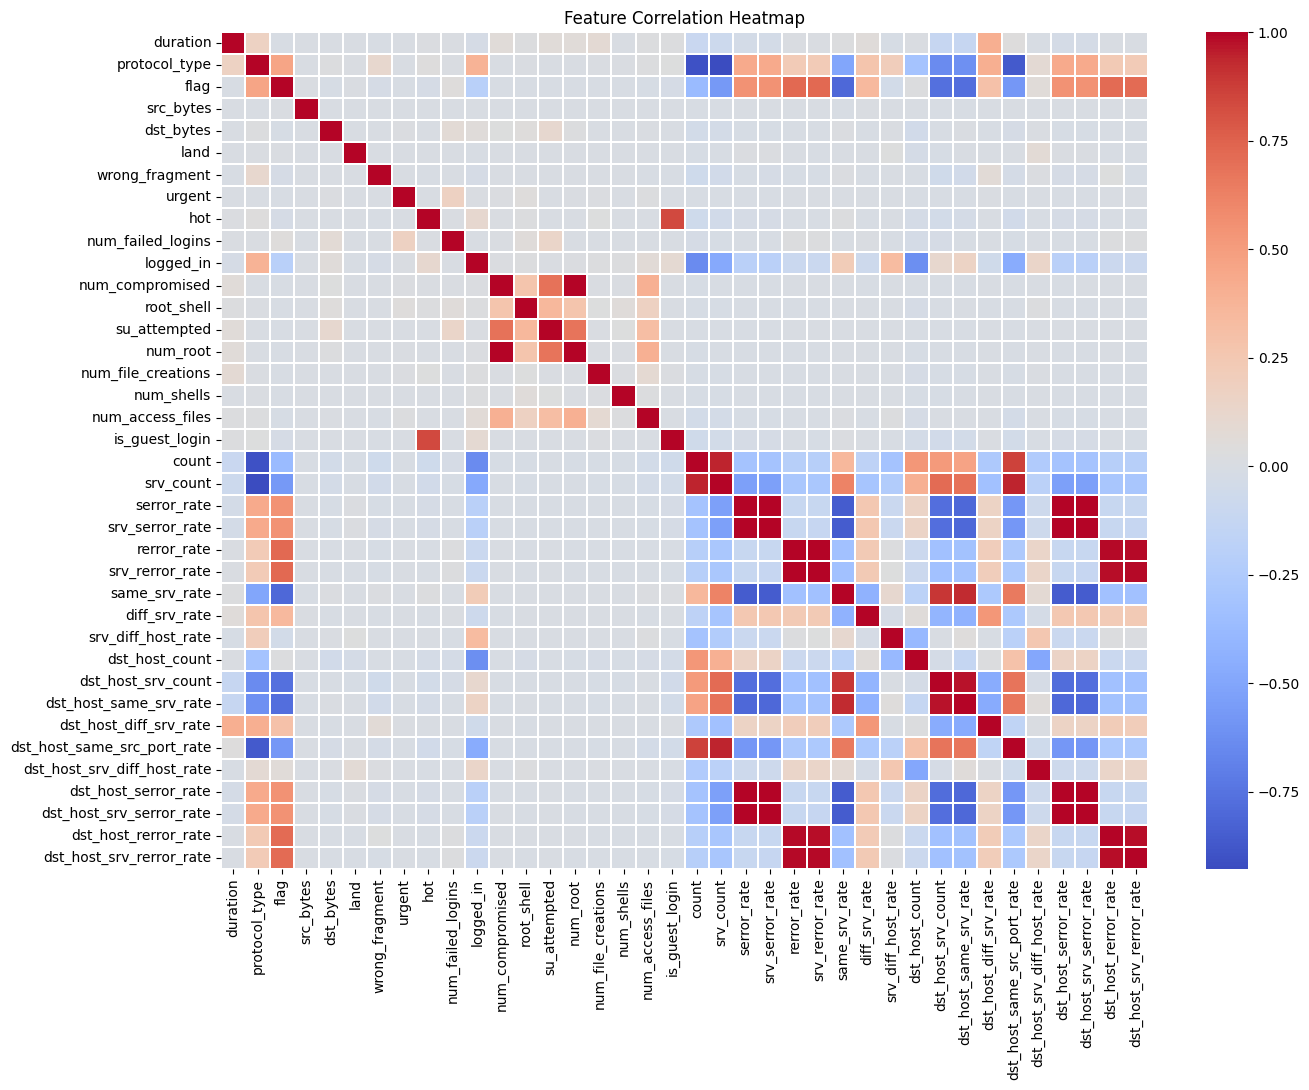

Dropped 11 highly correlated features
After dropping correlated features: (330994, 27)


In [ ]:
# Required imports
import seaborn as sns
import numpy as np

# Heatmap
plt.figure(figsize=(14, 11))
corr = X_train.corr()
sns.heatmap(corr, cmap='coolwarm', linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Automatically detect and drop highly correlated features
corr_matrix = X_train.corr().abs()

# Upper triangle of correlation matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Select features with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

# Drop from both train and test safely
X_train = X_train.drop(columns=to_drop, errors='ignore')
X_test = X_test.drop(columns=to_drop, errors='ignore')

print(f"Dropped {len(to_drop)} highly correlated features")
print(f"After dropping correlated features: {X_train.shape}")

In [ ]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

print(f"Scaled train shape: {X_train_scaled.shape}")
print(f"Scaled test shape:  {X_test_scaled.shape}")

Scaled train shape: (330994, 27)
Scaled test shape:  (163027, 27)


In [ ]:
# =========================
# REQUIRED IMPORTS
# =========================
import time
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# =========================
# SCALING
# =========================
sc = MinMaxScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

print(f"Scaled train shape: {X_train_scaled.shape}")
print(f"Scaled test shape:  {X_test_scaled.shape}")

# =========================
# MODELS (OPTIMIZED)
# =========================
models = {
    "Naive Bayes":         GaussianNB(),
    "Decision Tree":       DecisionTreeClassifier(max_depth=4),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=0),
}

results = []

# =========================
# TRAINING LOOP
# =========================
for name, model in models.items():
    print(f"\n⏳ Training {name}...")

    # Train
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - t0

    # Test
    t0 = time.time()
    y_pred = model.predict(X_test_scaled)
    test_time = time.time() - t0

    # Accuracy
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled)) * 100
    test_acc  = accuracy_score(y_test, y_pred) * 100

    # Store results
    results.append({
        'Model': name,
        'Train Accuracy (%)': round(train_acc, 2),
        'Test Accuracy (%)':  round(test_acc, 2),
        'Train Time (s)':     round(train_time, 2),
        'Test Time (s)':      round(test_time, 4),
    })

    print(f"✅ {name}: Train={train_acc:.2f}% | Test={test_acc:.2f}%")

    # IDS-critical metrics
    print("\n📊 Classification Report:")
    print(classification_report(y_test, y_pred))

# =========================
# RESULTS TABLE
# =========================
results_df = pd.DataFrame(results).set_index('Model')

print("\n📋 Final Results:")
print(results_df)

Scaled train shape: (330994, 27)
Scaled test shape:  (163027, 27)

⏳ Training Naive Bayes...
✅ Naive Bayes: Train=87.69% | Test=87.60%

📊 Classification Report:
              precision    recall  f1-score   support

         dos       0.98      0.94      0.96    129106
      normal       0.97      0.62      0.76     32167
       probe       0.09      0.98      0.17      1348
         r2l       0.28      0.38      0.32       387
         u2r       0.00      0.74      0.01        19

    accuracy                           0.88    163027
   macro avg       0.47      0.73      0.44    163027
weighted avg       0.97      0.88      0.91    163027


⏳ Training Decision Tree...
✅ Decision Tree: Train=99.31% | Test=99.26%

📊 Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

         dos       1.00      1.00      1.00    129106
      normal       0.98      0.99      0.98     32167
       probe       0.99      0.90      0.94      1348
         r2l       0.99      0.28      0.44       387
         u2r       0.00      0.00      0.00        19

    accuracy                           0.99    163027
   macro avg       0.79      0.63      0.67    163027
weighted avg       0.99      0.99      0.99    163027


⏳ Training Random Forest...
✅ Random Forest: Train=100.00% | Test=99.98%

📊 Classification Report:
              precision    recall  f1-score   support

         dos       1.00      1.00      1.00    129106
      normal       1.00      1.00      1.00     32167
       probe       1.00      0.99      1.00      1348
         r2l       0.99      0.97      0.98       387
         u2r       1.00      0.63      0.77        19

    accuracy                           1.00    163027
   macro avg       1.00      0.

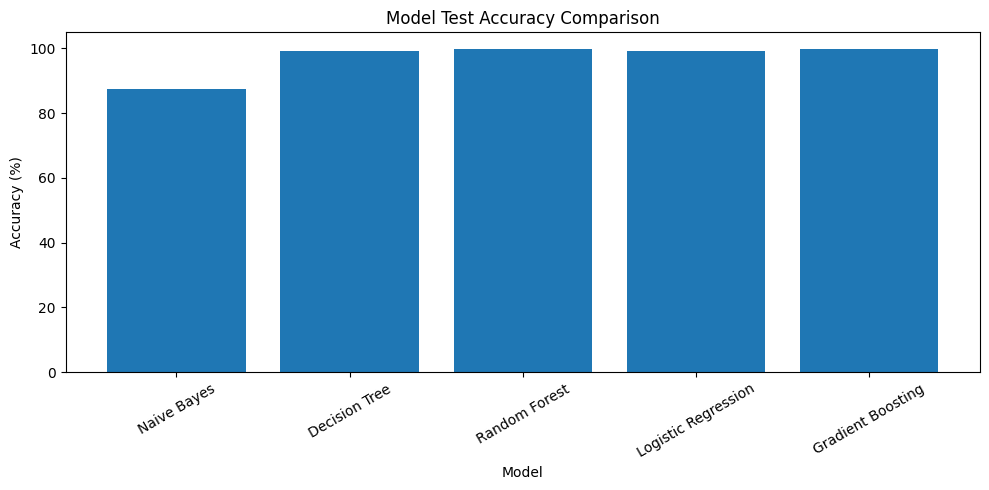

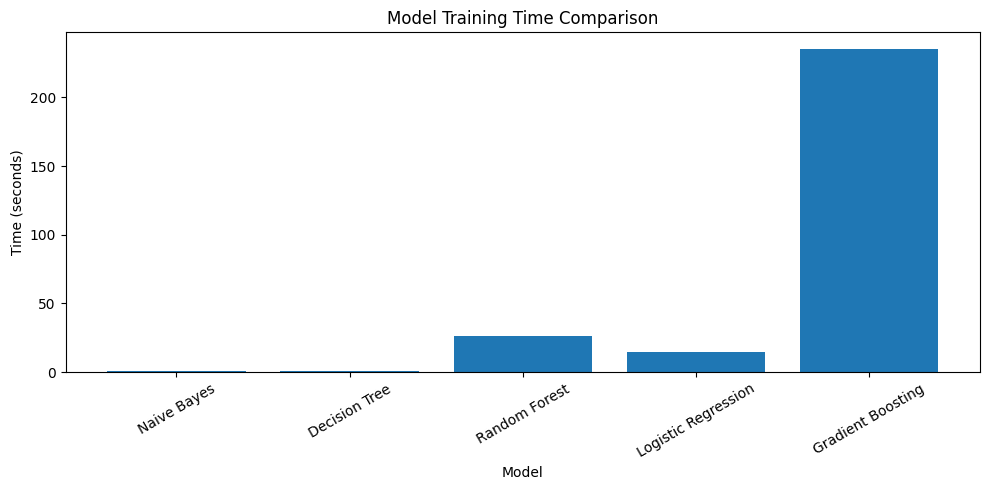

In [ ]:
import matplotlib.pyplot as plt

# Reset index for plotting
results_plot = results_df.reset_index()

# -------------------------
# Accuracy Comparison
# -------------------------
plt.figure(figsize=(10, 5))
plt.bar(results_plot['Model'], results_plot['Test Accuracy (%)'])
plt.xticks(rotation=30)
plt.title('Model Test Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()

# -------------------------
# Training Time Comparison
# -------------------------
plt.figure(figsize=(10, 5))
plt.bar(results_plot['Model'], results_plot['Train Time (s)'])
plt.xticks(rotation=30)
plt.title('Model Training Time Comparison')
plt.xlabel('Model')
plt.ylabel('Time (seconds)')
plt.tight_layout()
plt.show()

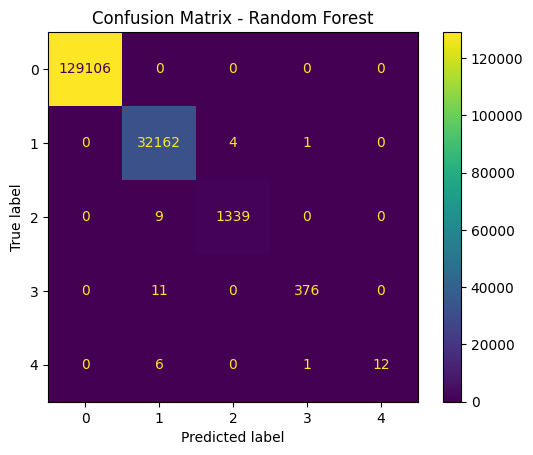

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

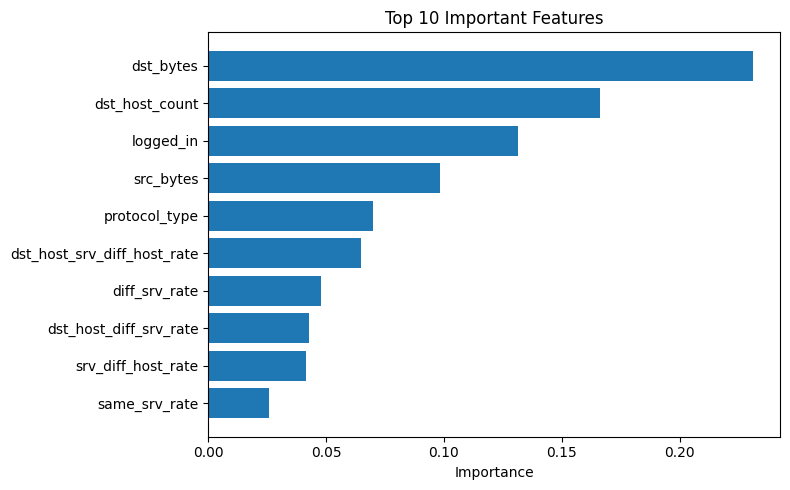

In [ ]:
import matplotlib.pyplot as plt

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

importances = model.feature_importances_
features = X_train.columns

# Sort
indices = importances.argsort()[-10:]  # top 10

plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()